# Дерево решений для классификации

## Сегодня на практическом занятии:
1. Узнаем, как считать количество вопросов, которое будет задаваться деревом решений на конкретном шаге
2. Разберемся со структурой дерева решений
3. Реализуем функцию подсчета критерия информативности Джини
4. Реализуем функцию подсчета прироста информации
5. Вручную пройдемся по процессу построения дерева решений

In [1]:
#@title Установка нужных версий библиотек
!pip install scikit-learn pandas matplotlib numpy 

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

ModuleNotFoundError: No module named 'sklearn'

### Получение данных

Будем работать с набором данных для задачи классификации - данные по сердечно сосудистым заболеваниям, довольно стандартный набор для изучения машинного обучения, но его нет в `sklearn'e`. Поэтому скачиваем данные со стороны, с google диска.

Ссылка на google drive: https://drive.google.com/file/d/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G


In [3]:
!wget 'https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G' -O cardio.csv

--2025-04-20 13:33:19--  https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G
Распознаётся drive.google.com (drive.google.com)… 108.177.14.194
Подключение к drive.google.com (drive.google.com)|108.177.14.194|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 303 See Other
Адрес: https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download [переход]
--2025-04-20 13:33:19--  https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download
Распознаётся drive.usercontent.google.com (drive.usercontent.google.com)… 173.194.73.132
Подключение к drive.usercontent.google.com (drive.usercontent.google.com)|173.194.73.132|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 2941524 (2,8M) [application/octet-stream]
Сохранение в: «cardio.csv»

cardio.csv          100%[===================>]   2,80M  2,90MB/s    за 1,0s    

2025-04-20 13:33:25 (2,

В задаче предалагается предсказать наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра. Датасет сформирован 3 групп признаков:

Объективные признаки:
- Возраст (в днях)
- Рост
- Вес
- Пол

Результаты измерения:

- Артериальное давление верхнее и нижнее
- Холестерин (три группы: норма, выше нормы, значительно выше нормы)
- Глюкоза (три группы: норма, выше нормы, значительно выше нормы)

Субъективные признаки (бинарные):

- Курение
- Употребление Алкоголя
- Физическая активность

In [ ]:
df = pd.read_csv('cardio.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
full_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [6]:
df['age'] = round(df['age'] / 365)

## 1. Вводная

### 1.1 Сколько вопросов будет задано на первом этапе

Посчитайте, сколько вопросов задаст дерево решений в самый первый раз, если использовать все признаки из списка full_features.

In [ ]:
# Ваш код здесь

def count_questions(df: pd.DataFrame, features: list[str]) -> int:
    _count_questions = 0
    for feature in features:
        _count_questions += df[feature].nunique() - 1 # последний вопрос задать некому)
    
    return _count_questions

print(f'Вопросов будет {count_questions(df, full_features)}')

Вопросов будет 737


### 1.2 Упростите задачу

Вопросов получилось достаточно, не будет моделировать столько вопросов, а попробуем уменьшить их количество.

Возьмите только два признака: weight и gluc.
А так же возьмите только 10 первых объектов.

In [ ]:
# Ваш код здесь

# Bruh, остатки вышки или кого там, другие признак надо
features = ['cholesterol', 'age']
df = df[features + [target]]
df = df.iloc[:6] # тоже типа Bruh, в задание 10
df

,cholesterol,age,cardio
0,1,50.0,0
1,3,55.0,1
2,3,52.0,1
3,1,48.0,1
4,1,48.0,0
5,2,60.0,0


### 1.3 Посчитайте еще раз, сколько будет вопросов

In [ ]:
# Ваш код здесь

print(f'Вопросов будет {count_questions(df, features)}')

Вопросов будет 6


С таким количеством вопросов уже можем работать и разбираться в устройству дерева решений.

## 2. Устройство дерева решений

### 2.1 Обучите дерево решений

Обучите дерево решений из sklearn'a с атрибутом `random_state=1`.

In [ ]:
# Ваш код здесь

from sklearn.tree import DecisionTreeClassifier

# random_state тут для псевдо-жадного сэмплирования, читайте доку
tree = DecisionTreeClassifier(random_state=1)
tree.fit(df[features], df[target])

DecisionTreeClassifier(random_state=1)

### 2.2 Отрисуйте обученное дерево решений

Нарисуйте дерево решений, которое у вас получилось после обучения. Сделайте отрисовку такой, чтобы можно было понять, какие вопросы задаются

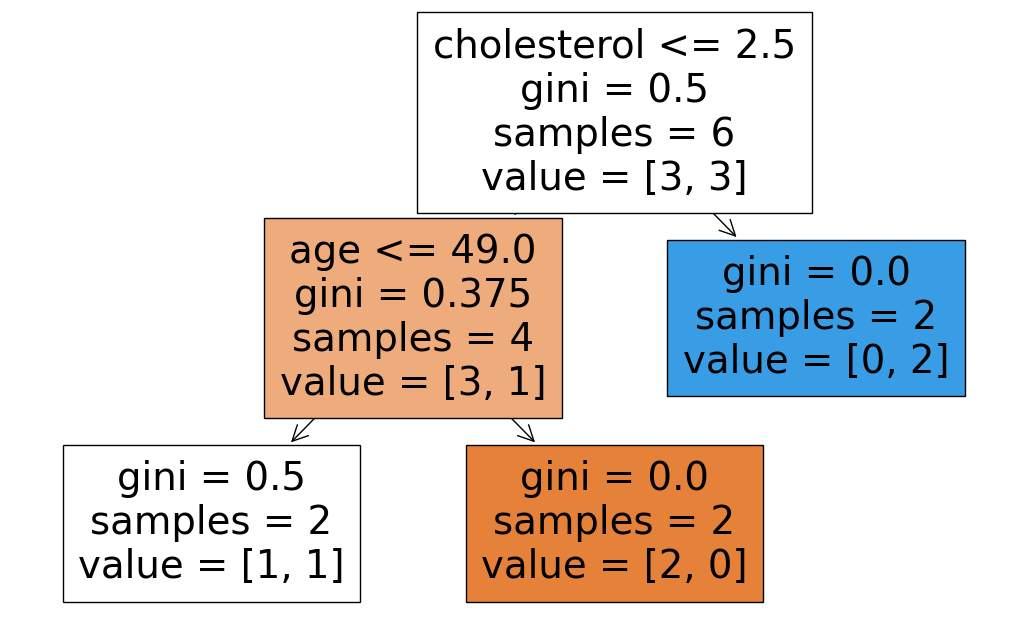

In [ ]:
# Ваш код здесь

plt.figure(figsize=(13, 8))
plot_tree(tree, feature_names=features, filled=True);

### 2.3 Посчитайте, сколько вершин получилось

In [17]:
# Ваши выводы здесь можно без кода, просто посчитайте


Получилось 2 вершины, одна с вопросом cholesterol <= 2.5, а вторая с вопросом age <= 49.

### 2.4 Посчитайте, сколько листов получилось

In [18]:
# Ваши выводы здесь

print(3)

3


### 2.5 Посмотрите, почему не получилось сделать разбиение ещё на два узла в крайнем левом узле.

В узле, где
```
gini=0.5
samples=2
value=[1, 1]
```

In [19]:
# Ваш код/вывод здесь

df[(df['cholesterol'] <= 2.5) & (df['age'] <= 49)]

,cholesterol,age,cardio
3,1,48.0,1
4,1,48.0,0


Не получилось дальше сделать разбиение, потому что получили два абсолютно одинаковых объекта, но с разными классами.

## 3. Вспомогательные функции

Для того, что бы дальше сравнивать между собой объекты нужно реализовать две вспомогательные функции.

### 3.1 Функция подсчета критерия Джини

Функция должна принимать список целевых значений, считать критерий информативности и выдавать одно значение - критерий Джини.

Можно было бы опираться на формулу подсчета значения:

$$H(X) = \sum^{K}_{k=1}p_{k}(1-p_{k}) = 1 - \sum_{k=1}^K{p_k^2} ,$$

где $K$ - количество классов в наборе данных $X$,
а $p_k$ - доля объектов класса $k$ в выборке $X$:

In [ ]:
# Ваш код здесь

def gini(labels):
    """
    на вход labels - целевые значения
    на выходе подсчитанный джини
    """

    #  подсчет количества объектов разных классов
    classes = {}
    for label in labels:
        if label not in classes:
            classes[label] = 0
        classes[label] += 1

    #  расчет критерия
    gini = 0
    for label in classes:
        p = classes[label] / len(labels)
        gini += p * (1 - p)

    return gini

### 3.2 Проверка функции gini

Посчитайте критерий информативности в исходной выборке и вы должны получить точно такое же значение, как и было на визуализации дерева решений в его корне.

Самописный Джини в корне дерева 0.5


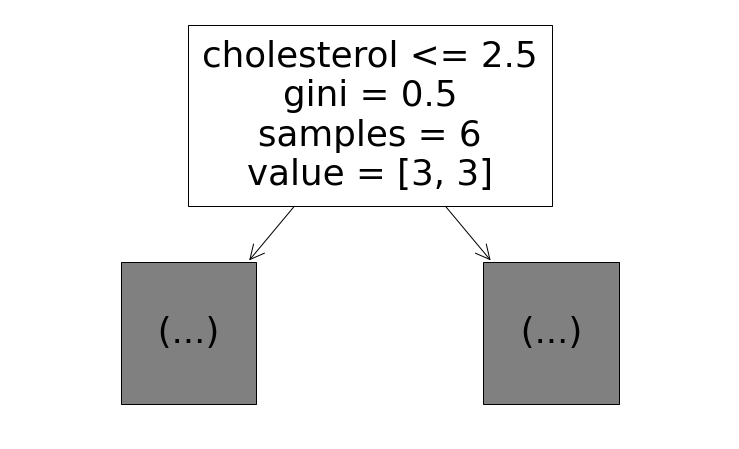

In [ ]:
# Ваш код здесь

plt.figure(figsize=(13, 8))
plot_tree(tree, feature_names=features, filled=True, max_depth=0);

print(f'Самописный Джини в корне дерева {gini(list(df[target]))}')

### 3.3 Функция подсчета прироста информации

Функция должна принимать целевые значения левой подвыборки, правой подвыборки и исходной вершины, а выдавать должна одно значение - прирост информации, подсчитанный на критерии информативности Джини.

Можно было пользоваться этой формулой:

$$Q(X_{m}, j, t) = H(X_{m}) - \frac{|X_{l}|}{|X_{m}|}H(X_{l}) - \frac{|X_{r}|}{|X_{m}|}H(X_{r})$$


In [ ]:
# Ваш код здесь


def gain(left_labels, right_labels, root_labels):

    # доля выборки, ушедшая в левое поддерево
    p = float(left_labels.shape[0]) / (left_labels.shape[0] + right_labels.shape[0])
    IG = gini(root_labels) - p * gini(left_labels) - (1 - p) * gini(right_labels)

    return IG

Теперь вспомогательные функции готовы можем моделировать работу обученного дерева решений.

## 4. Процесс построения дерева решений

### 4.1 Получение первого вопроса


4.1.1 Пройдитесь по всем возможным вопросам для исходного набора данных


Можете сохранять полученные значения прироста информации в датафрейм в удобную для вас структуру данных.

In [ ]:
# Ваш код здесь

def calcualte_gain(df: pd.DataFrame, features: list[str], target: str = "cardio") -> pd.DataFrame:
    results = pd.DataFrame(columns=['feature', 'value', 'IG'])
    # проход по все признакам
    for feature in features:
        # проход по всем уникальным значения
        # (при этом можем брать и невалидные вопросы)
        # (у них просто будет нулевой IG)
        for t in df[feature].unique():
            y_left = df[df[feature] <= t][target]
            y_right = df[df[feature] > t][target]
            ig = gain(y_left, y_right, df[target])

            # записываем результаты
            results = results.append({
                'feature': feature,
                'value': t,
                'IG': ig
            }, ignore_index=True)
    return results

results = calcualte_gain(df, features, target)
results

,feature,value,IG
0,cholesterol,1,0.055556
1,cholesterol,3,0.000000
2,cholesterol,2,0.250000
3,age,50,0.055556
4,age,55,0.100000
5,age,52,0.000000
6,age,48,0.000000
7,age,60,0.000000


4.1.2 Найдите самый лучший вопрос, опираясь на прирост информации

In [ ]:
# Ваш код здесь

results.sort_values(by='IG', ascending=False).iloc[0]

feature    cholesterol
value                2
IG                0.25
Name: 2, dtype: object

4.1.3. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [ ]:
# Ваш код здесь

df_left = df[df['cholesterol'] <= 2]
df_right = df[df['cholesterol'] > 2]

In [ ]:
display(df_left, df_right)

,cholesterol,age,cardio
0,1,50.0,0
3,1,48.0,1
4,1,48.0,0
5,2,60.0,0


,cholesterol,age,cardio
1,3,55.0,1
2,3,52.0,1


4.1.4. Проверьте себя через визуализацию дерева решений

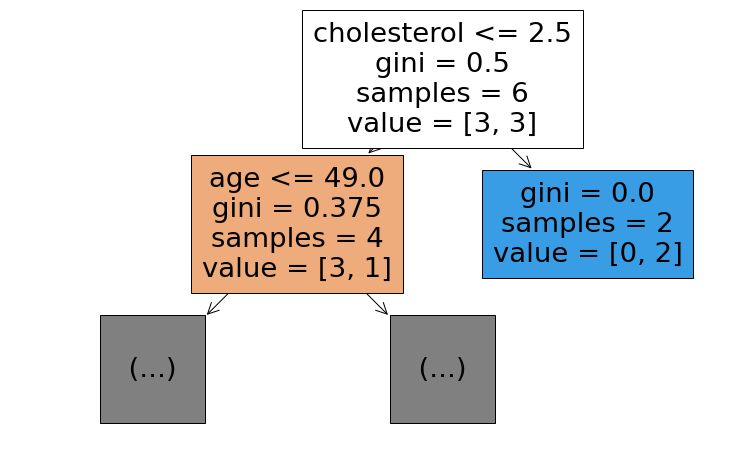

In [ ]:
# Ваш код здесь

plt.figure(figsize=(13, 8))
plot_tree(tree, feature_names=features, filled=True, max_depth=1);

### 4.2 Получение второго вопроса


4.2.1. Глядя на df_left и df_right, посмотрите, где можно сделать ещё разбиение

In [ ]:
# Ваш вывод здесь

Правая выборка в себе содержит только объекты первого класса, поэтому разбивать её дальше не имеет смысла, поэтому будем дальше работать с левой выборкой.

4.2.2. Пройдитесь по всем признакам в выбранной подвыборке

In [ ]:
# Ваш код здесь

df = df_left.copy()
results_2 = calcualte_gain(df, features, target)
results_2

,feature,value,IG
0,cholesterol,1,0.041667
1,cholesterol,2,0.000000
2,age,50,0.041667
3,age,48,0.125000
4,age,60,0.000000


4.2.3 Найдите самый лучший вопрос, опираясь на прирост информации

In [ ]:
# Ваш код здесь

results_2.sort_values(by='IG', ascending=False).iloc[0]

feature      age
value         48
IG         0.125
Name: 3, dtype: object

4.2.4. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [ ]:
# Ваш код здесь

df_left = df[df['age'] <= 48]
df_right = df[df['age'] > 48]

In [ ]:
display(df_left, df_right)

,cholesterol,age,cardio
3,1,48.0,1
4,1,48.0,0


,cholesterol,age,cardio
0,1,50.0,0
5,2,60.0,0


4.2.5. Проверьте себя через визуализацию дерева решений

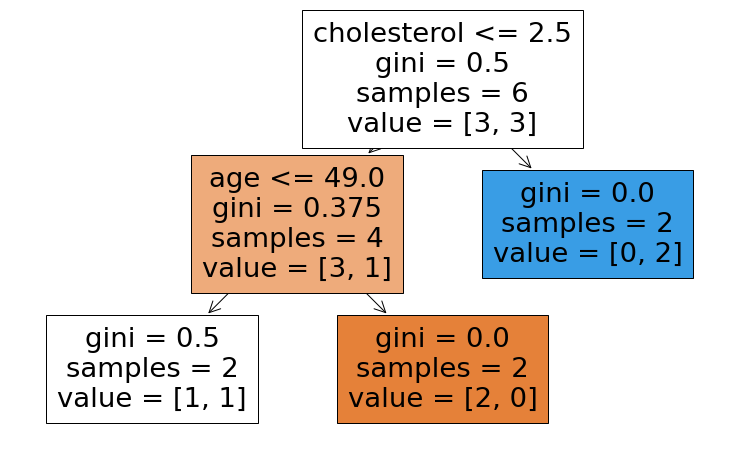

In [ ]:
# Ваш код здесь

plt.figure(figsize=(13, 8))
plot_tree(tree, feature_names=features, filled=True, max_depth=2);

4.2.6. Если что-то не сошлось, посмотрите, в чем может быть проблема

In [ ]:
# Ваш код/вывод здесь

У нас получился самый лучший вопрос `age <= 48`, а в визуализированном дереве решений `age <= 49`.

Так вышло, потому что есть две стратегии, как задавать вопросы:
1. Можно через уникальные значения в признаказ (как мы делали)
2. А можно через средние значения отсортированных уникальных значений

Проверим, а точно ли это так.

Вопрос с визуализированного дерева решений.

In [ ]:
display(df[df['age'] <= 49], df[df['age'] > 49])

,cholesterol,age,cardio
3,1,48.0,1
4,1,48.0,0


,cholesterol,age,cardio
0,1,50.0,0
5,2,60.0,0


Вопрос с нашего прохода.

In [ ]:
display(df[df['age'] <= 48], df[df['age'] > 48])

,cholesterol,age,cardio
3,1,48.0,1
4,1,48.0,0


,cholesterol,age,cardio
0,1,50.0,0
5,2,60.0,0


Они получились полностью одинаковыми, так что мы всё сделали верно.

## Резюме

Сегодня на практическом занятии:
1. Узнали, как считать количество вопросов, которое будет задаваться деревом решений на конкретном шаге
2. Разобрались со структурой дерева решений
3. Реализовали функцию подсчета критерия информативности Джини
4. Реализовали функцию подсчета прироста информации
5. Вручную прошлись по процессу построения дерева решений